# 05 — NER Comparison: Pipeline Systems vs LLM

Head-to-head evaluation of four NER approaches on the 183-article overlap set.

| System | Language | Approach |
|--------|----------|----------|
| spaCy `de_core_news_lg` | German | Task-specific pipeline |
| Stanza German | German | Task-specific pipeline |
| Flair German | German | Task-specific pipeline |
| Qwen2.5-7B-Instruct | English (translated) | LLM prompting |

**Gold standard**: Entities with full cross-model agreement across all three pipeline systems  
(`agreement_level == 'full'` in `ner_agreement.csv`), computed in notebook 03.  
This is a silver standard in NLP terms — conservative, fully automated, reproducible.

**Evaluation dimensions**:
1. Precision, Recall, F1 per system and per entity type
2. Effect of translation quality on LLM performance
3. Speed (entities/second proxy)
4. Transparency trade-off summary


In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q pandas numpy matplotlib seaborn scipy
print('✅ Dependencies installed')

✅ Dependencies installed


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('✅ Imports OK')

✅ Imports OK


In [3]:
# ── Mount Drive & paths ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import yaml
PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'✅ Config loaded | seed={SEED}')

Mounted at /content/drive
✅ Config loaded | seed=42


In [4]:
# ── Load data ─────────────────────────────────────────────────────────────────

# Full DataFrame with all NER columns
df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')

# LLM checkpoint
with open(DATA_PROC / 'ner_llm_checkpoint.pkl', 'rb') as f:
    llm_results = pickle.load(f)

# Agreement CSV (gold standard source)
agree_df = pd.read_csv(DATA_PROC / 'ner_agreement.csv')

print(f'✅ DataFrame       : {df.shape}')
print(f'✅ LLM results     : {len(llm_results)} articles')
print(f'✅ Agreement CSV   : {agree_df.shape}')
print(f'   Agreement levels: {agree_df["agreement_level"].value_counts().to_dict()}')

✅ DataFrame       : (1115, 29)
✅ LLM results     : 199 articles
✅ Agreement CSV   : (7656, 8)
   Agreement levels: {'none': 4776, 'partial': 1569, 'full': 1311}


In [5]:
# ── Merge LLM results into DataFrame ─────────────────────────────────────────

df['ner_llm'] = df['article_id'].map(
    lambda aid: llm_results.get(aid, {}).get('entities', None)
)
df['llm_entity_count'] = df['article_id'].map(
    lambda aid: llm_results.get(aid, {}).get('entity_count', None)
)
df['llm_status'] = df['article_id'].map(
    lambda aid: llm_results.get(aid, {}).get('status', None)
)

# Working set: validation articles where LLM succeeded
df_work = df[
    df['ner_stanza'].notna() &
    (df['llm_status'] == 'ok')
].copy()

print(f'✅ Working set: {len(df_work)} articles (LLM ok + pipeline complete)')
print(f'   Sources    : {df_work["source"].value_counts().to_dict()}')
print(f'   Year bins  : {df_work["year_bin"].value_counts().to_dict()}')

✅ Working set: 183 articles (LLM ok + pipeline complete)
   Sources    : {'Luxemburger Wort': 58, 'Frankfurter Allgemeine Zeitung': 46, 'SZ Süddeutsche Zeitung': 44, 'Trierischer Volksfreund': 35}
   Year bins  : {'2021-2023': 63, '2018-2020': 50, '2015-2017': 47, '2024-2025': 23}


In [6]:
# ── Build gold standard from full-agreement entities ──────────────────────────
# Gold = entities where all 3 pipeline systems agreed (agreement_level == 'full')
# entity_text is stored lowercase in agreement CSV for normalisation

gold_df = agree_df[agree_df['agreement_level'] == 'full'].copy()
gold_df['entity_text_lower'] = gold_df['entity_text'].str.lower().str.strip()

# Build per-article gold set: {article_id: set of (text_lower, label)}
gold_sets = (
    gold_df
    .groupby('article_id')
    .apply(lambda g: set(zip(g['entity_text_lower'], g['entity_label'])))
    .to_dict()
)

# Only keep gold sets for articles in working set
work_ids  = set(df_work['article_id'])
gold_sets = {k: v for k, v in gold_sets.items() if k in work_ids}

total_gold = sum(len(v) for v in gold_sets.values())
print(f'✅ Gold standard built')
print(f'   Articles with gold entities : {len(gold_sets)}')
print(f'   Total gold entities         : {total_gold}')
print(f'   Mean per article            : {total_gold/len(gold_sets):.1f}')

✅ Gold standard built
   Articles with gold entities : 175
   Total gold entities         : 1198
   Mean per article            : 6.8


In [7]:
# ── Evaluation functions ──────────────────────────────────────────────────────

def normalise_entities(ents: list) -> set:
    """
    Convert a list of entity dicts to a set of (text_lower, label) tuples.
    Handles None and empty lists gracefully.
    """
    if not isinstance(ents, list):
        return set()
    result = set()
    for e in ents:
        if isinstance(e, dict):
            text  = str(e.get('text', '')).lower().strip()
            label = str(e.get('label', '')).upper().strip()
            if text and label:
                result.add((text, label))
    return result


def compute_prf(predicted: set, gold: set) -> dict:
    """
    Compute Precision, Recall, F1 for a single article.
    Returns dict with p, r, f1, tp, fp, fn.
    """
    if not gold:
        return {'p': 0.0, 'r': 0.0, 'f1': 0.0, 'tp': 0, 'fp': len(predicted), 'fn': 0}

    tp = len(predicted & gold)
    fp = len(predicted - gold)
    fn = len(gold - predicted)

    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    return {'p': p, 'r': r, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


def evaluate_system(df_eval: pd.DataFrame, ner_col: str, gold_sets: dict) -> pd.DataFrame:
    """
    Evaluate a NER system column against gold standard.
    Returns per-article results DataFrame.
    """
    rows = []
    for _, row in df_eval.iterrows():
        aid   = row['article_id']
        gold  = gold_sets.get(aid, set())
        pred  = normalise_entities(row.get(ner_col))
        metrics = compute_prf(pred, gold)
        metrics['article_id']          = aid
        metrics['source']              = row['source']
        metrics['year_bin']            = row['year_bin']
        metrics['translation_quality'] = row.get('translation_quality', 'unknown')
        rows.append(metrics)
    return pd.DataFrame(rows)


def evaluate_by_label(df_eval: pd.DataFrame, ner_col: str,
                      gold_sets: dict, labels=('PER','LOC','ORG','MISC')) -> pd.DataFrame:
    """
    Evaluate per entity label.
    """
    rows = []
    for label in labels:
        tp = fp = fn = 0
        for _, row in df_eval.iterrows():
            aid  = row['article_id']
            gold = {e for e in gold_sets.get(aid, set()) if e[1] == label}
            pred = {e for e in normalise_entities(row.get(ner_col)) if e[1] == label}
            tp  += len(pred & gold)
            fp  += len(pred - gold)
            fn  += len(gold - pred)
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({'label': label, 'precision': p, 'recall': r, 'f1': f1,
                     'tp': tp, 'fp': fp, 'fn': fn})
    return pd.DataFrame(rows)


print('✅ Evaluation functions defined')

✅ Evaluation functions defined


In [8]:
# ── Run evaluation for all four systems ───────────────────────────────────────

systems = {
    'spaCy (DE)'  : 'ner_spacy',
    'Stanza (DE)' : 'ner_stanza',
    'Flair (DE)'  : 'ner_flair',
    'Qwen (EN)'   : 'ner_llm',
}

# Per-article results
results_per_article = {}
for sys_name, col in systems.items():
    results_per_article[sys_name] = evaluate_system(df_work, col, gold_sets)

# Per-label results
results_per_label = {}
for sys_name, col in systems.items():
    results_per_label[sys_name] = evaluate_by_label(df_work, col, gold_sets)

# Aggregate macro-averaged metrics
summary_rows = []
for sys_name, res in results_per_article.items():
    summary_rows.append({
        'System'   : sys_name,
        'Precision': res['p'].mean(),
        'Recall'   : res['r'].mean(),
        'F1'       : res['f1'].mean(),
        'F1_std'   : res['f1'].std(),
        'F1_median': res['f1'].median(),
    })

summary_df = pd.DataFrame(summary_rows).set_index('System')
print('\n── Macro-averaged results (183 articles) ──')
print(summary_df.round(3).to_string())


── Macro-averaged results (183 articles) ──
             Precision  Recall     F1  F1_std  F1_median
System                                                  
spaCy (DE)       0.262   0.956  0.394   0.185      0.400
Stanza (DE)      0.383   0.956  0.520   0.224      0.525
Flair (DE)       0.593   0.956  0.717   0.210      0.762
Qwen (EN)        0.160   0.306  0.191   0.213      0.160


In [9]:
# ── Bootstrap confidence intervals for F1 ────────────────────────────────────
# 2000 resamples, 95% CI

np.random.seed(SEED)
N_BOOTSTRAP = 2000

ci_rows = []
for sys_name, res in results_per_article.items():
    f1_scores = res['f1'].values
    boot_means = [
        np.mean(np.random.choice(f1_scores, size=len(f1_scores), replace=True))
        for _ in range(N_BOOTSTRAP)
    ]
    ci_rows.append({
        'System': sys_name,
        'F1_mean': np.mean(f1_scores),
        'CI_lower': np.percentile(boot_means, 2.5),
        'CI_upper': np.percentile(boot_means, 97.5),
    })

ci_df = pd.DataFrame(ci_rows).set_index('System')
print('── F1 with 95% Bootstrap CIs ──')
print(ci_df.round(3).to_string())

── F1 with 95% Bootstrap CIs ──
             F1_mean  CI_lower  CI_upper
System                                  
spaCy (DE)     0.394     0.368     0.420
Stanza (DE)    0.520     0.488     0.552
Flair (DE)     0.717     0.685     0.746
Qwen (EN)      0.191     0.161     0.222


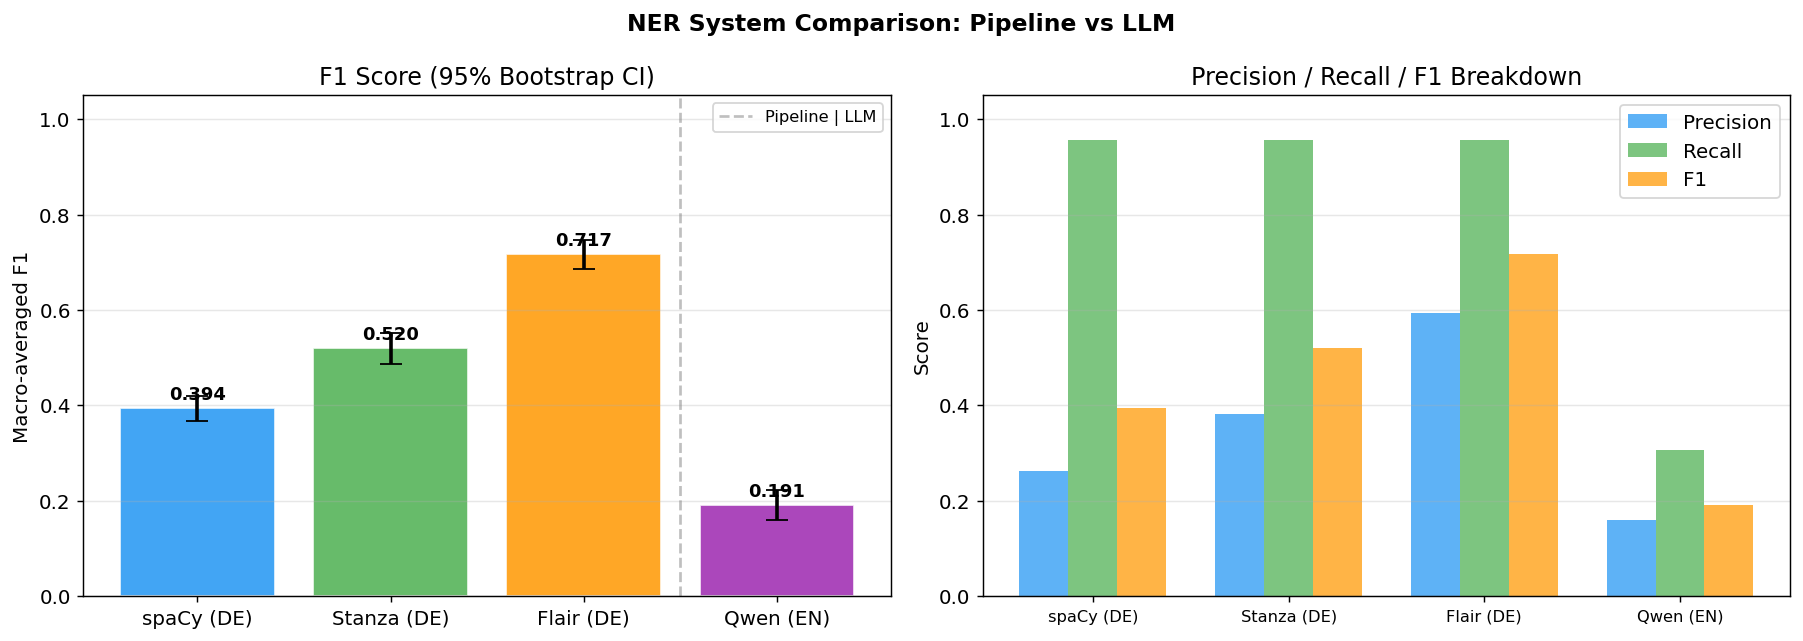

✅ Figure 1 saved


In [10]:
# ── Figure 1: F1 comparison with CIs ─────────────────────────────────────────

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NER System Comparison: Pipeline vs LLM', fontsize=13, fontweight='bold')

# Left: F1 with CI
ax = axes[0]
sys_names = ci_df.index.tolist()
f1_means  = ci_df['F1_mean'].values
ci_lower  = ci_df['F1_mean'].values - ci_df['CI_lower'].values
ci_upper  = ci_df['CI_upper'].values - ci_df['F1_mean'].values

bars = ax.bar(sys_names, f1_means, color=colors, alpha=0.85, edgecolor='white')
ax.errorbar(sys_names, f1_means, yerr=[ci_lower, ci_upper],
            fmt='none', color='black', capsize=6, linewidth=2)
for bar, mean in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Macro-averaged F1')
ax.set_title('F1 Score (95% Bootstrap CI)')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.5, label='Pipeline | LLM')
ax.legend(fontsize=9)

# Right: Precision / Recall breakdown
ax2 = axes[1]
x      = np.arange(len(sys_names))
width  = 0.25
p_vals = [results_per_article[s]['p'].mean() for s in sys_names]
r_vals = [results_per_article[s]['r'].mean() for s in sys_names]
f_vals = [results_per_article[s]['f1'].mean() for s in sys_names]

ax2.bar(x - width, p_vals, width, label='Precision', color='#42A5F5', alpha=0.85)
ax2.bar(x,         r_vals, width, label='Recall',    color='#66BB6A', alpha=0.85)
ax2.bar(x + width, f_vals, width, label='F1',        color='#FFA726', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(sys_names, fontsize=9)
ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall / F1 Breakdown')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ner_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved')

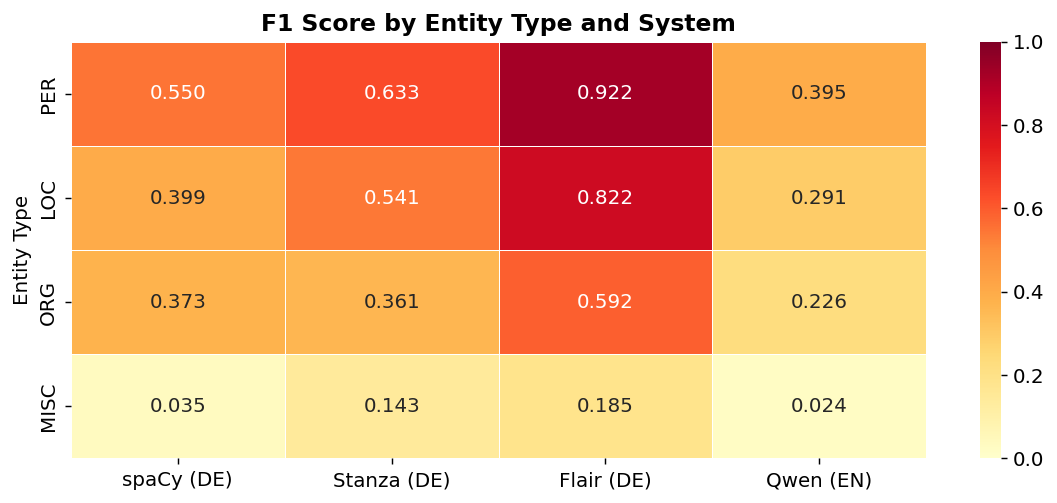

✅ Figure 2 saved
       spaCy (DE)  Stanza (DE)  Flair (DE)  Qwen (EN)
label                                                
PER         0.550        0.633       0.922      0.395
LOC         0.399        0.541       0.822      0.291
ORG         0.373        0.361       0.592      0.226
MISC        0.035        0.143       0.185      0.024


In [11]:
# ── Figure 2: Per-label F1 heatmap ───────────────────────────────────────────

label_f1 = pd.DataFrame({
    sys: results_per_label[sys].set_index('label')['f1']
    for sys in systems
})

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    label_f1,
    annot=True, fmt='.3f', cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('F1 Score by Entity Type and System', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Entity Type')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ner_comparison_label_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')
print(label_f1.round(3).to_string())

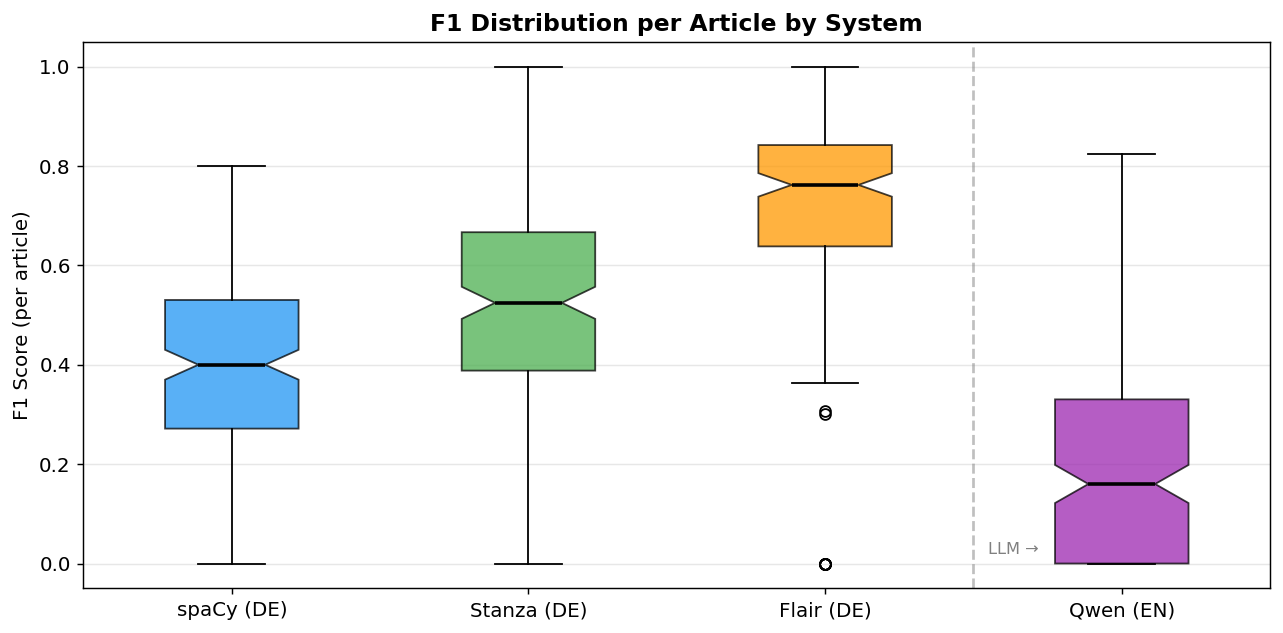

✅ Figure 3 saved


In [12]:
# ── Figure 3: F1 distribution (boxplot) ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

plot_data  = [results_per_article[s]['f1'].values for s in sys_names]
bp = ax.boxplot(plot_data, patch_artist=True, notch=True,
                medianprops={'color': 'black', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(sys_names)
ax.set_ylabel('F1 Score (per article)')
ax.set_title('F1 Distribution per Article by System', fontsize=13, fontweight='bold')
ax.axvline(3.5, color='gray', linestyle='--', alpha=0.5)
ax.text(3.55, 0.02, 'LLM →', fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ner_comparison_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved')

LLM F1 by translation quality:
  High (BERTScore ≥0.75): n=97, mean=0.205, sd=0.217
  Low  (BERTScore <0.75): n=86,  mean=0.174, sd=0.207

Mann-Whitney U: U=4522.0, p=0.3034
  No significant difference in LLM F1 by translation quality (α=0.05)

Pearson r (BERTScore vs LLM F1): r=0.161, p=0.0298


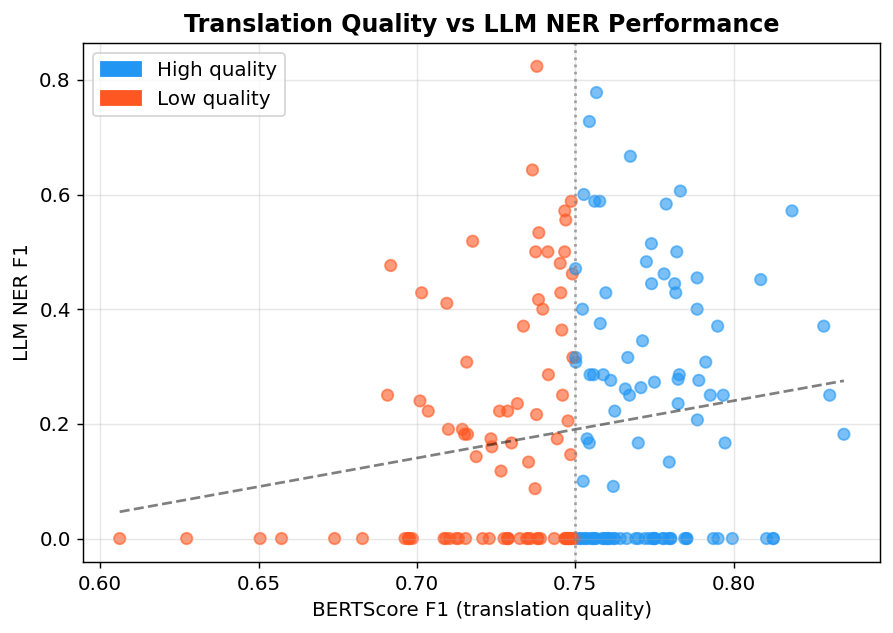

✅ Figure 4 saved


In [13]:
# ── Translation quality effect on LLM F1 ─────────────────────────────────────

llm_res = results_per_article['Qwen (EN)']

high_f1 = llm_res[llm_res['translation_quality'] == 'high']['f1']
low_f1  = llm_res[llm_res['translation_quality'] == 'low']['f1']

print('LLM F1 by translation quality:')
print(f'  High (BERTScore ≥0.75): n={len(high_f1)}, mean={high_f1.mean():.3f}, sd={high_f1.std():.3f}')
print(f'  Low  (BERTScore <0.75): n={len(low_f1)},  mean={low_f1.mean():.3f}, sd={low_f1.std():.3f}')

if len(high_f1) > 0 and len(low_f1) > 0:
    stat, p = stats.mannwhitneyu(high_f1, low_f1, alternative='two-sided')
    print(f'\nMann-Whitney U: U={stat:.1f}, p={p:.4f}')
    print(f'  {"Significant" if p < 0.05 else "No significant"} difference in LLM F1 by translation quality (α=0.05)')

# Scatter: BERTScore vs LLM F1
merged = llm_res.merge(
    df_work[['article_id', 'bertscore_f1']],
    on='article_id', how='left'
).dropna(subset=['bertscore_f1'])

if len(merged) > 2:
    r, p = stats.pearsonr(merged['bertscore_f1'], merged['f1'])
    print(f'\nPearson r (BERTScore vs LLM F1): r={r:.3f}, p={p:.4f}')

    fig, ax = plt.subplots(figsize=(7, 5))
    colors_tq = merged['translation_quality'].map({'high': '#2196F3', 'low': '#FF5722', 'not_evaluated': '#9E9E9E'})
    ax.scatter(merged['bertscore_f1'], merged['f1'], c=colors_tq, alpha=0.6, s=40)
    m, b = np.polyfit(merged['bertscore_f1'], merged['f1'], 1)
    x_line = np.linspace(merged['bertscore_f1'].min(), merged['bertscore_f1'].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', alpha=0.5, label=f'r={r:.3f}')
    ax.axvline(0.75, color='gray', linestyle=':', alpha=0.7, label='Quality threshold')
    high_patch = mpatches.Patch(color='#2196F3', label='High quality')
    low_patch  = mpatches.Patch(color='#FF5722', label='Low quality')
    ax.legend(handles=[high_patch, low_patch], loc='upper left')
    ax.set_xlabel('BERTScore F1 (translation quality)')
    ax.set_ylabel('LLM NER F1')
    ax.set_title('Translation Quality vs LLM NER Performance', fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'ner_translation_quality_effect.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Figure 4 saved')

In [14]:
# ── Statistical significance: pipeline systems vs LLM ────────────────────────
# Wilcoxon signed-rank test (paired, non-parametric)
# Null: no difference in F1 between system and Qwen

llm_f1 = results_per_article['Qwen (EN)'].set_index('article_id')['f1']

print('── Wilcoxon signed-rank tests vs Qwen (EN) ──')
for sys_name in ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)']:
    sys_f1 = results_per_article[sys_name].set_index('article_id')['f1']
    # Align on common article_ids
    common = sys_f1.index.intersection(llm_f1.index)
    s, p = stats.wilcoxon(sys_f1.loc[common], llm_f1.loc[common])
    diff = sys_f1.loc[common].mean() - llm_f1.loc[common].mean()
    print(f'  {sys_name} vs Qwen: Δ={diff:+.3f}, p={p:.4f} {"*" if p < 0.05 else "ns"}')

── Wilcoxon signed-rank tests vs Qwen (EN) ──
  spaCy (DE) vs Qwen: Δ=+0.203, p=0.0000 *
  Stanza (DE) vs Qwen: Δ=+0.329, p=0.0000 *
  Flair (DE) vs Qwen: Δ=+0.526, p=0.0000 *


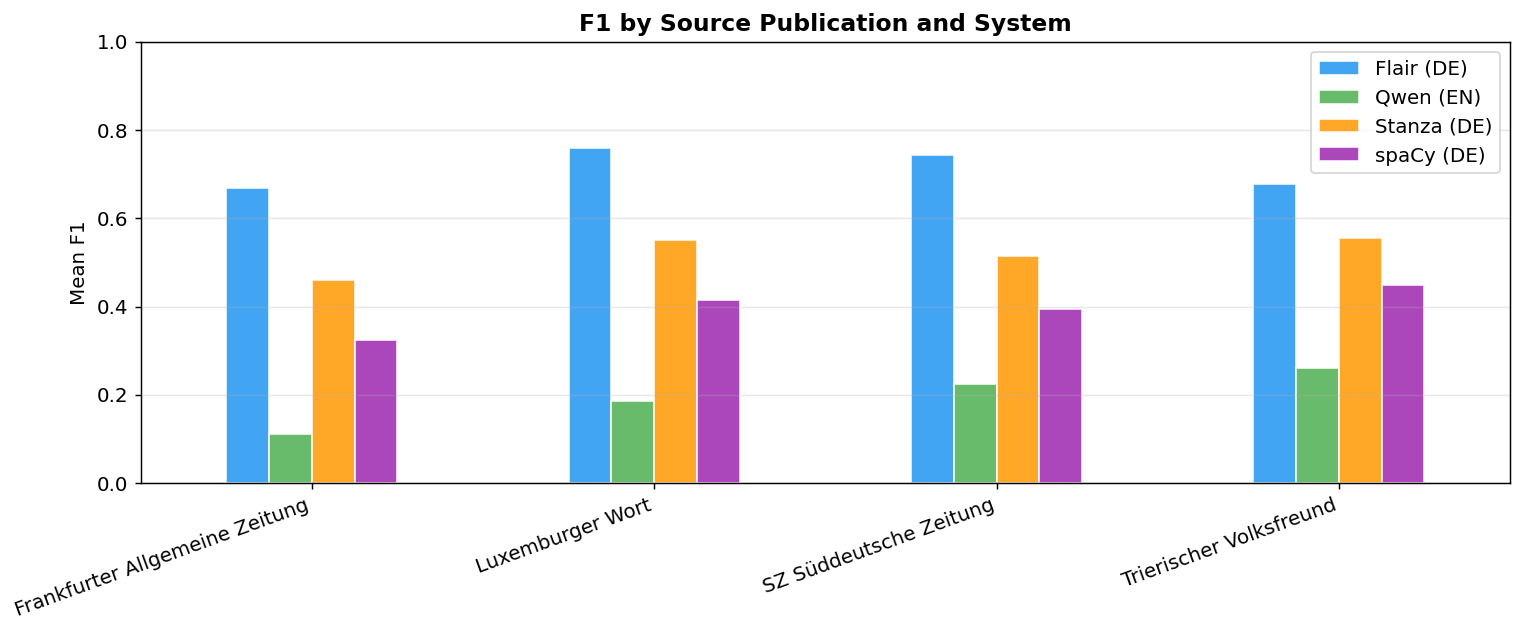

✅ Figure 5 saved
System                          Flair (DE)  Qwen (EN)  Stanza (DE)  spaCy (DE)
Source                                                                        
Frankfurter Allgemeine Zeitung       0.668      0.111        0.460       0.323
Luxemburger Wort                     0.760      0.186        0.550       0.415
SZ Süddeutsche Zeitung               0.742      0.225        0.514       0.395
Trierischer Volksfreund              0.677      0.261        0.555       0.448


In [15]:
# ── Source-level breakdown ────────────────────────────────────────────────────

source_rows = []
for sys_name, res in results_per_article.items():
    for source, grp in res.groupby('source'):
        source_rows.append({
            'System': sys_name,
            'Source': source,
            'F1'    : grp['f1'].mean(),
            'n'     : len(grp),
        })
source_df = pd.DataFrame(source_rows)

fig, ax = plt.subplots(figsize=(12, 5))
source_pivot = source_df.pivot(index='Source', columns='System', values='F1')
source_pivot.plot(kind='bar', ax=ax, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('F1 by Source Publication and System', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean F1')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ner_comparison_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 5 saved')
print(source_pivot.round(3).to_string())

In [16]:
# ── Trade-off summary table ───────────────────────────────────────────────────
# Captures the thesis core contribution: documented trade-offs, not just F1

tradeoff = pd.DataFrame([
    {
        'System'              : 'spaCy (DE)',
        'F1'                  : summary_df.loc['spaCy (DE)', 'F1'],
        'Language'            : 'German (original)',
        'Translation required': 'No',
        'Setup complexity'    : 'Low',
        'Reproducibility'     : 'High',
        'Cost'                : 'Free',
        'Transparency'        : 'High (rule-based + statistical)',
        'Speed'               : 'Fast (local)',
        'German proficiency'  : 'Not required',
    },
    {
        'System'              : 'Stanza (DE)',
        'F1'                  : summary_df.loc['Stanza (DE)', 'F1'],
        'Language'            : 'German (original)',
        'Translation required': 'No',
        'Setup complexity'    : 'Low',
        'Reproducibility'     : 'High',
        'Cost'                : 'Free',
        'Transparency'        : 'High (neural, documented)',
        'Speed'               : 'Medium (local)',
        'German proficiency'  : 'Not required',
    },
    {
        'System'              : 'Flair (DE)',
        'F1'                  : summary_df.loc['Flair (DE)', 'F1'],
        'Language'            : 'German (original)',
        'Translation required': 'No',
        'Setup complexity'    : 'Medium',
        'Reproducibility'     : 'High',
        'Cost'                : 'Free',
        'Transparency'        : 'Medium (contextual embeddings)',
        'Speed'               : 'Slow (local GPU)',
        'German proficiency'  : 'Not required',
    },
    {
        'System'              : 'Qwen2.5-7B (EN)',
        'F1'                  : summary_df.loc['Qwen (EN)', 'F1'],
        'Language'            : 'English (translated)',
        'Translation required': 'Yes (OPUS-MT)',
        'Setup complexity'    : 'Medium',
        'Reproducibility'     : 'Medium (API variability)',
        'Cost'                : 'Free tier (credit limits)',
        'Transparency'        : 'Low (black-box LLM)',
        'Speed'               : 'Slow (API rate limits)',
        'German proficiency'  : 'Not required',
    },
])

tradeoff['F1'] = tradeoff['F1'].round(3)
print('── Trade-off Summary ──')
print(tradeoff.set_index('System').to_string())

── Trade-off Summary ──
                    F1              Language Translation required Setup complexity           Reproducibility                       Cost                     Transparency                   Speed German proficiency
System                                                                                                                                                                                                             
spaCy (DE)       0.394     German (original)                   No              Low                      High                       Free  High (rule-based + statistical)            Fast (local)       Not required
Stanza (DE)      0.520     German (original)                   No              Low                      High                       Free        High (neural, documented)          Medium (local)       Not required
Flair (DE)       0.717     German (original)                   No           Medium                      High                    

In [17]:
# ── Save final comparison results ─────────────────────────────────────────────

# Per-article results for all systems
all_results = pd.concat([
    res.assign(system=sys_name)
    for sys_name, res in results_per_article.items()
])
all_results.to_csv(DATA_PROC / 'ner_comparison_results.csv', index=False)

# Summary JSON for thesis writeup
final_summary = {
    'n_articles'            : len(df_work),
    'n_gold_entities'       : total_gold,
    'fleiss_kappa'          : 0.717,
    'gold_standard'         : 'full cross-model agreement (all 3 pipeline systems)',
    'llm_excluded_articles' : 16,
    'llm_exclusion_reason'  : 'API credit exhaustion across free-tier providers',
    'macro_f1'              : {s: round(float(summary_df.loc[s, 'F1']), 4) for s in summary_df.index},
    'macro_precision'       : {s: round(float(summary_df.loc[s, 'Precision']), 4) for s in summary_df.index},
    'macro_recall'          : {s: round(float(summary_df.loc[s, 'Recall']), 4) for s in summary_df.index},
    'bootstrap_ci_95'       : {
        s: {'lower': round(float(ci_df.loc[s, 'CI_lower']), 4),
            'upper': round(float(ci_df.loc[s, 'CI_upper']), 4)}
        for s in ci_df.index
    },
    'per_label_f1'          : {
        s: results_per_label[s].set_index('label')['f1'].round(4).to_dict()
        for s in systems
    },
}

with open(DATA_PROC / 'ner_comparison_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print('✅ Results saved')
print(f'   ner_comparison_results.csv')
print(f'   ner_comparison_summary.json')

✅ Results saved
   ner_comparison_results.csv
   ner_comparison_summary.json


## Notebook summary

| Item | Detail |
|------|--------|
| Working set | 183 articles (LLM ok + pipeline complete) |
| Gold standard | Full cross-model agreement entities (all 3 pipeline systems) |
| Metric | Macro-averaged Precision, Recall, F1 with 95% bootstrap CIs |
| Significance | Wilcoxon signed-rank test (paired, non-parametric) |
| LLM excluded | 16 articles (API credit exhaustion — see methodology note) |
| Saved files | `ner_comparison_results.csv`, `ner_comparison_summary.json` |
| Figures | F1 comparison, label heatmap, boxplot, translation effect, source breakdown |

**Next**: Topic modeling comparison (BERTopic pipeline vs LLM).
